# Student Performance on HSC Exam


Dataset: **Student Performance Bangladesh**

Link: https://data.mendeley.com/datasets/5nvsv7ypg4/3

## 1. Import Libraries

In [1]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## 2. Load dataset


In [2]:
df = pd.read_csv("/Users/sadikurrahmankhan/Documents/Machine Learning Projects/Bangladeshi Student Permormance on HSC exam/bangladesh_student_performance.csv")

# Show first 5 rows
df.head(5)

,date,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result,hsc_result
0,29/04/2018,M,18,Rural,GT3,Together,3,2,At_home,Farmer,No,No,71672,4,4.22,3.72
1,29/04/2018,F,19,Rural,LE3,Apart,0,4,Other,Health,Yes,No,26085,5,3.47,2.62
2,29/04/2018,F,19,Rural,GT3,Together,0,3,Teacher,Services,No,No,40891,3,3.32,2.56
3,29/04/2018,F,19,Rural,LE3,Apart,2,3,At_home,Business,No,No,50600,2,4.57,4.17
4,29/04/2018,M,17,Rural,GT3,Together,1,1,At_home,Farmer,No,No,62458,2,4.50,3.94


The dataset includes a diverse set of features that are believed to influence academic outcomes. These features cover a wide range of domains such as:

Demographic Information: Age, gender, parental education, and occupation.

Academic History: Previous grades, subject preferences, study time, tutoring, etc.

Socioeconomic Factors: Family income, number of siblings, living location (urban/rural).

Institutional Factors: Type of school/college (public/private), distance from home, teacher-student ratio, etc.

Lifestyle and Behavioral Aspects: Sleep habits, screen time, daily routines, mental health indicators, and parental support.

##  3. Basic Data Information

In [3]:
# Number of rows and columns
print("Shape:", df.shape)

Shape: (2018, 16)


In [4]:
# Column names
df.columns

Index(['date', 'gender', 'age', 'address', 'famsize', 'Pstatus', 'M_Edu',
       'F_Edu', 'M_Job', 'F_Job', 'relationship', 'smoker', 'tuition_fee',
       'time_friends', 'ssc_result', 'hsc_result'],
      dtype='object')

In [5]:
# Data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2018 entries, 0 to 2017
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          2018 non-null   object 
 1   gender        2018 non-null   object 
 2   age           2018 non-null   int64  
 3   address       2018 non-null   object 
 4   famsize       2018 non-null   object 
 5   Pstatus       2018 non-null   object 
 6   M_Edu         2018 non-null   int64  
 7   F_Edu         2018 non-null   int64  
 8   M_Job         2018 non-null   object 
 9   F_Job         2018 non-null   object 
 10  relationship  2018 non-null   object 
 11  smoker        2018 non-null   object 
 12  tuition_fee   2018 non-null   int64  
 13  time_friends  2018 non-null   int64  
 14  ssc_result    2018 non-null   float64
 15  hsc_result    2018 non-null   float64
dtypes: float64(2), int64(5), object(9)
memory usage: 252.4+ KB


In [6]:
# Check missing values
df.isnull().sum()

date            0
gender          0
age             0
address         0
famsize         0
Pstatus         0
M_Edu           0
F_Edu           0
M_Job           0
F_Job           0
relationship    0
smoker          0
tuition_fee     0
time_friends    0
ssc_result      0
hsc_result      0
dtype: int64

In [7]:
# Quick descriptive statistics for numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,2018.0,17.981169,0.826340,17.0,17.00,18.00,19.00,19.0
M_Edu,2018.0,1.871160,1.194206,0.0,1.00,2.00,3.00,4.0
F_Edu,2018.0,2.174430,1.252979,0.0,1.00,2.00,3.00,4.0
tuition_fee,2018.0,72977.637760,24045.222595,25102.0,53619.50,71272.50,90904.75,129168.0
time_friends,2018.0,3.059960,1.439190,1.0,2.00,3.00,4.00,5.0
ssc_result,2018.0,3.788087,0.622376,2.0,3.36,3.77,4.23,5.0
hsc_result,2018.0,3.199177,0.604526,2.0,2.78,3.16,3.58,5.0


## Define Target and Feature Types

In [8]:
target_col = "hsc_result"

numeric_cols = [
    "age",
    "M_Edu",
    "F_Edu",
    "tuition_fee",
    "time_friends",
    "ssc_result"
]

categorical_cols = [
    "date",
    "gender",
    "address",
    "famsize",
    "Pstatus",
    "M_Job",
    "F_Job",
    "relationship",
    "smoker"
]

print("Target:", target_col)
print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)


Target: hsc_result
Numeric columns: ['age', 'M_Edu', 'F_Edu', 'tuition_fee', 'time_friends', 'ssc_result']
Categorical columns: ['date', 'gender', 'address', 'famsize', 'Pstatus', 'M_Job', 'F_Job', 'relationship', 'smoker']


# 4. Exploratory Data Analysis(EDA)

In [9]:
for c in categorical_cols:
    print(c, df[c].unique())

date ['29/04/2018']
gender ['M' 'F']
address ['Rural' 'Urban']
famsize ['GT3' 'LE3']
Pstatus ['Together' 'Apart']
M_Job ['At_home' 'Other' 'Teacher' 'Services' 'Health']
F_Job ['Farmer' 'Health' 'Services' 'Business' 'Teacher']
relationship ['No' 'Yes']
smoker ['No' 'Yes']


## 5. Understanding Distributions with Histograms and Boxplots

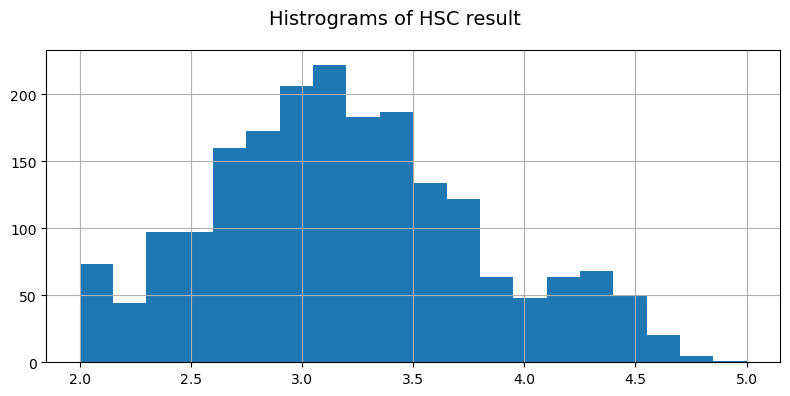

In [10]:
# Histograms for numeric features
df["hsc_result"].hist(bins=20, figsize=(8,4))
plt.suptitle("Histrograms of HSC result", fontsize = 14)
plt.tight_layout()
plt.show()

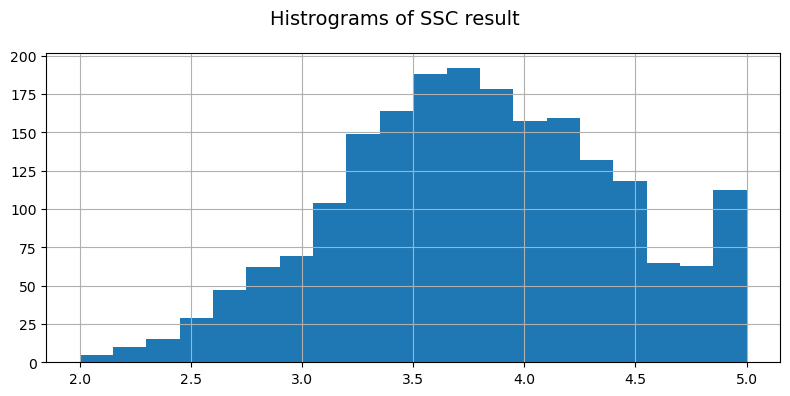

In [11]:
# Histograms for numeric features
df["ssc_result"].hist(bins=20, figsize=(8,4))
plt.suptitle("Histrograms of SSC result", fontsize = 14)
plt.tight_layout()
plt.show()

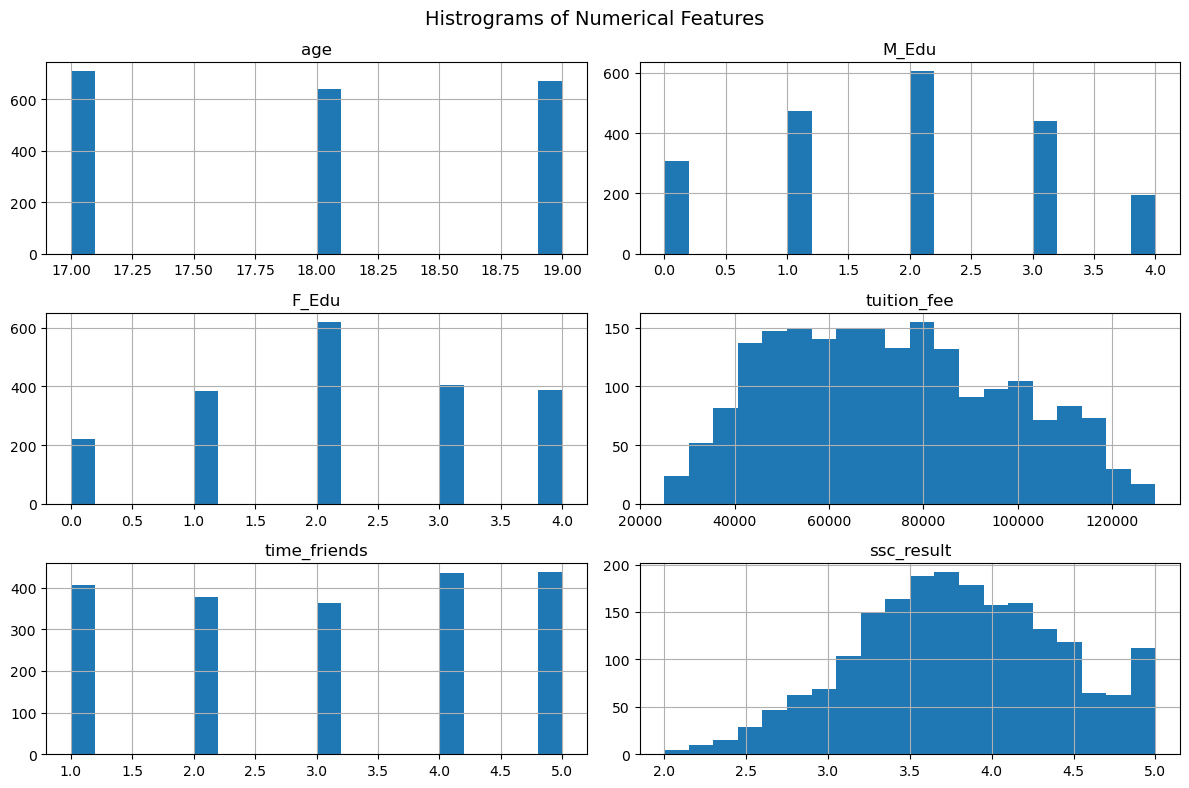

In [12]:
df[numeric_cols].hist(bins=20,figsize=(12,8))
plt.suptitle("Histrograms of Numerical Features", fontsize = 14)
plt.tight_layout()
plt.show()

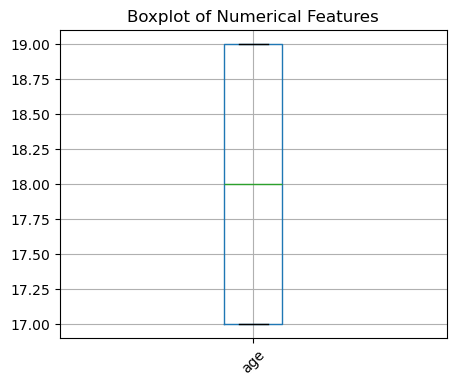

In [13]:
# Boxplots to get a sense of spread and possible outliers
plt.figure(figsize=(5,4))
df.boxplot(column=numeric_cols[0])
plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=45)
plt.show()

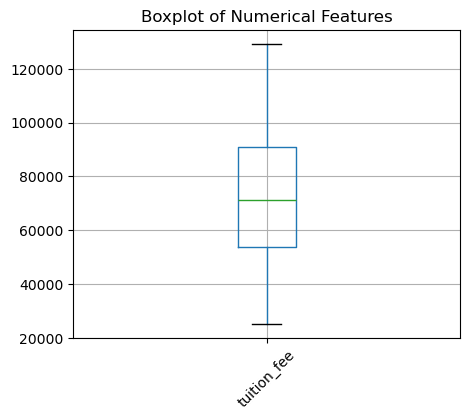

In [14]:
# Boxplots to get a sense of spread and possible outliers
plt.figure(figsize=(5,4))
df.boxplot(column=numeric_cols[3])
plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=45)
plt.show()

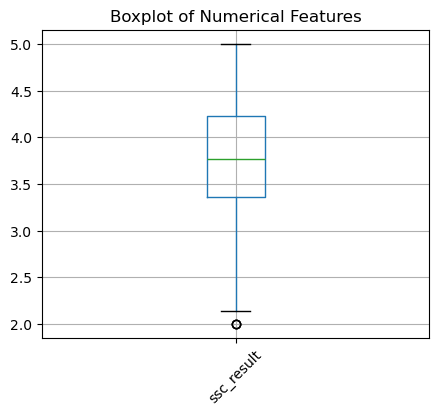

In [15]:
# Boxplots to get a sense of spread and possible outliers
plt.figure(figsize=(5,4))
df.boxplot(column=numeric_cols[5])
plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=45)
plt.show()

## 6. Categorical Feature Exploration

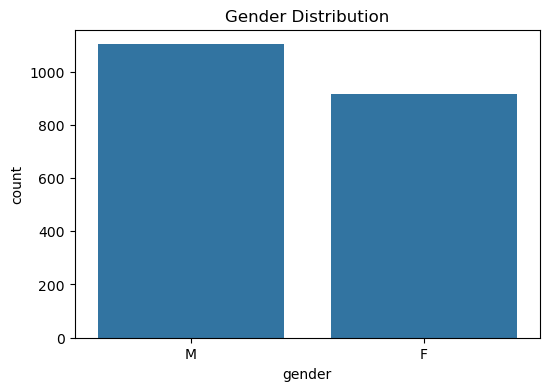

In [16]:
# Count Plot for Categorical Features

plt.figure(figsize=(6,4))
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()

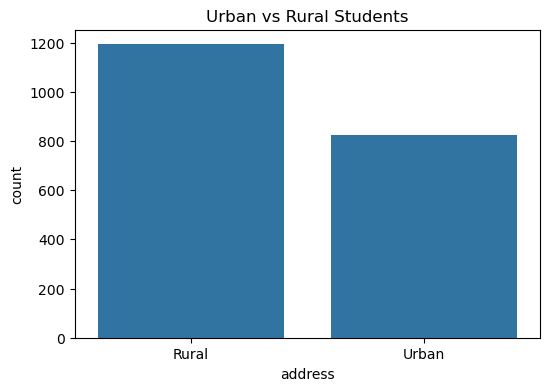

In [17]:
# Address Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='address', data=df)
plt.title("Urban vs Rural Students")
plt.show()

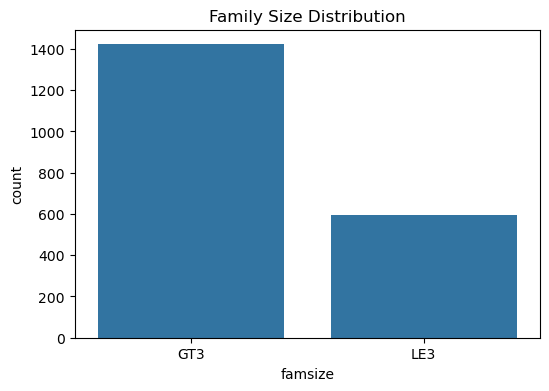

In [18]:
# Family Size Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='famsize', data=df)
plt.title("Family Size Distribution")
plt.show()

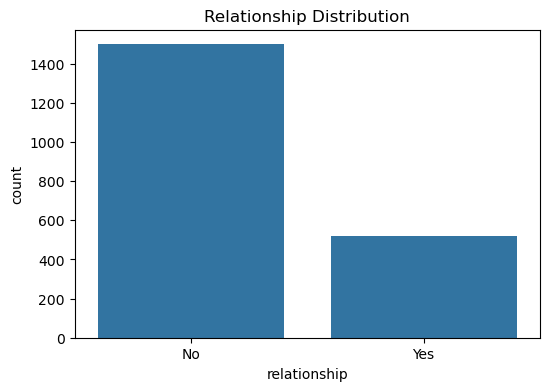

In [19]:
# Relationship Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='relationship', data=df)
plt.title("Relationship Distribution")
plt.show()

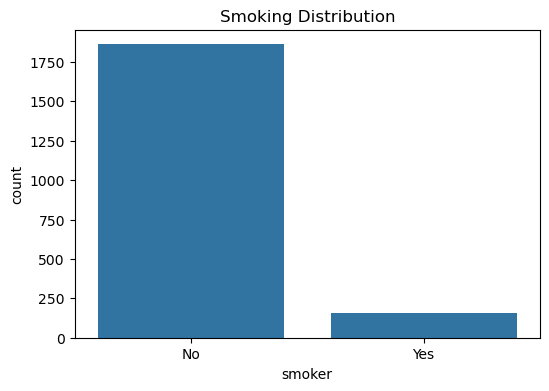

In [20]:
# Smoker
plt.figure(figsize=(6,4))
sns.countplot(x='smoker', data=df)
plt.title("Smoking Distribution")
plt.show()

<!-- # 4. Rename Columns (for simplicity) -->

## 7. Relationships Between Features and Target

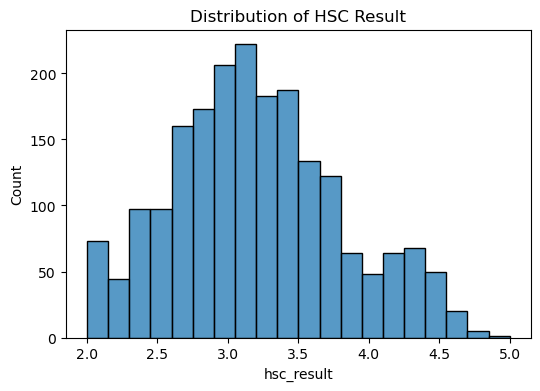

In [22]:
# Distribution of HSC Result

plt.figure(figsize=(6,4))
sns.histplot(df['hsc_result'], bins=20)
plt.title("Distribution of HSC Result")
plt.show()

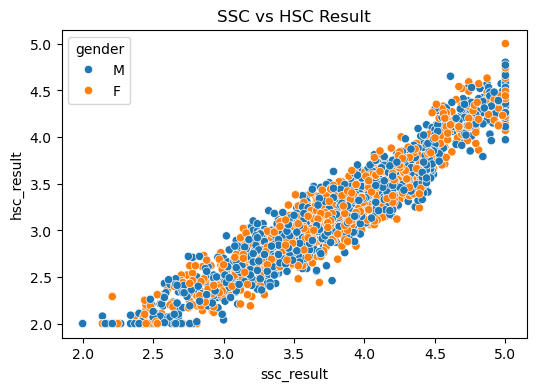

In [23]:
# SSC vs HSC Relationship

plt.figure(figsize=(6,4))
# sns.scatterplot(x=df['ssc_result'], y=df['hsc_result'])
sns.scatterplot(x="ssc_result", y="hsc_result", hue="gender", data=df)
plt.title("SSC vs HSC Result")
plt.show()

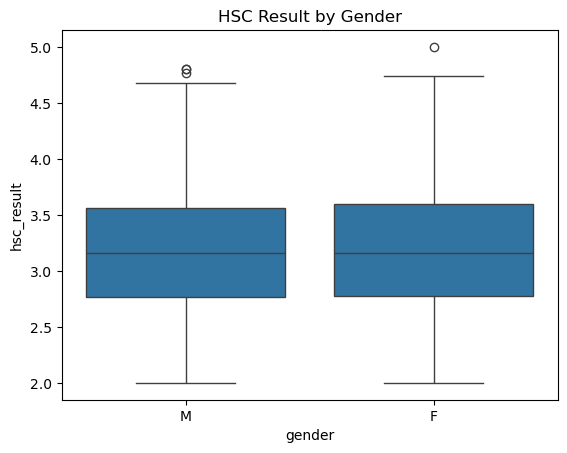

In [24]:
# Gender vs HSC Result

sns.boxplot(x=df['gender'], y=df['hsc_result'])
plt.title("HSC Result by Gender")
plt.show()

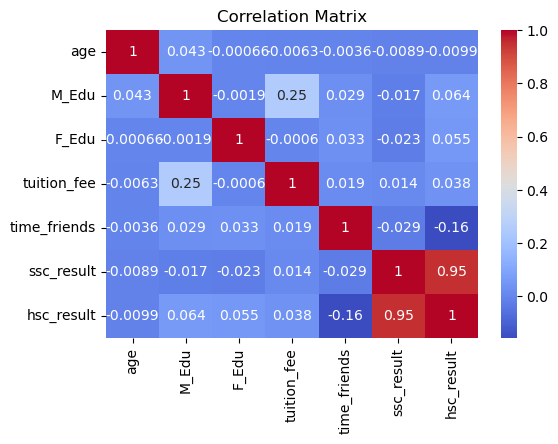

In [25]:
# Correlation Heatmap

plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()